# Phần 1. NumPy trong workflow ML/DL

Các bài dưới đây dùng dữ liệu nhỏ để mô phỏng preprocessing, inference và xử lý
tensor trong một pipeline thực tế.

TRƯƠNG ANH PHÚC 2510197

In [52]:
STUDENT_NAME = ""  # TODO: Họ và tên
STUDENT_ID = ""    # TODO: MSSV

print(f"Student: {STUDENT_NAME} ({STUDENT_ID})")

Student:  ()


In [53]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (8, 4.8)

DATA_CANDIDATES = [
    Path("week02/numpy-pandas-eda-hw/data/automobile_raw.csv"),
    Path("data/automobile_raw.csv"),
    Path("../data/automobile_raw.csv"),
]
DATA_PATH = next((path for path in DATA_CANDIDATES if path.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("Không tìm thấy data/automobile_raw.csv")

print("Data path:", DATA_PATH.resolve())

Data path: D:\BKU\VSC\mliot-pyml-2026-hw\week02\numpy-pandas-eda-hw\data\automobile_raw.csv


## N1. Stable softmax cho batch logits

Một classifier trả về `logits` có shape `(batch_size, num_classes)`. Tính softmax
theo từng mẫu bằng cách trừ giá trị lớn nhất trên mỗi hàng trước khi gọi `np.exp`.
Cách viết này tránh overflow khi logits có giá trị lớn.

**Biến đầu ra bắt buộc**

- `shifted_logits`: logits sau khi trừ row-wise maximum.
- `class_probabilities`: xác suất mỗi class, mỗi hàng có tổng bằng 1.
- `predicted_classes`: class có xác suất lớn nhất của từng mẫu.
- `confidence_scores`: xác suất lớn nhất của từng mẫu.

In [54]:
logits = np.array([
    [2.0, 1.0, 0.1],
    [1000.0, 1001.0, 999.0],
    [-2.0, -1.0, 3.0],
    [0.5, 0.5, 0.5],
], dtype=np.float64)

In [55]:
# TODO N1
shifted_logits = logits - np.max(logits, axis=1, keepdims=True)

exp_logits = np.exp(shifted_logits)

class_probabilities = exp_logits / np.sum(exp_logits, axis=1, keepdims=True)

predicted_classes = np.argmax(class_probabilities, axis=1)

confidence_scores = np.max(class_probabilities, axis=1)

In [56]:
required = [
    "shifted_logits",
    "class_probabilities",
    "predicted_classes",
    "confidence_scores",
]
if not all(name in globals() for name in required):
    print("Complete N1 to run this self-check.")
else:
    assert class_probabilities.shape == logits.shape
    assert np.all(np.isfinite(class_probabilities))
    assert np.allclose(class_probabilities.sum(axis=1), 1.0)
    assert predicted_classes.shape == (logits.shape[0],)
    assert confidence_scores.shape == (logits.shape[0],)
    print("N1 self-check passed")

N1 self-check passed


## N2. Chuẩn hóa train và validation không gây leakage

Mỗi hàng là một mẫu, mỗi cột là một feature. Tính mean/std **chỉ từ `X_train`**,
sau đó dùng cùng thống kê để transform cả train và validation.

**Biến đầu ra bắt buộc**

- `train_feature_mean`, `train_feature_std`: shape `(4,)`.
- `X_train_scaled`: train set đã chuẩn hóa.
- `X_val_scaled`: validation set dùng thống kê từ train.

In [57]:
# Features: height_cm, weight_kg, activity_hours, age
X_train = np.array([
    [170.0, 65.0, 1.2, 22.0],
    [180.0, 80.0, 2.4, 35.0],
    [160.0, 50.0, 0.8, 19.0],
    [175.0, 70.0, 1.5, 28.0],
    [168.0, 60.0, 1.0, 24.0],
    [182.0, 90.0, 3.0, 41.0],
])

X_val = np.array([
    [172.0, 68.0, 1.4, 26.0],
    [190.0, 95.0, 3.4, 45.0],
])

In [58]:
# TODO N2
train_feature_mean = np.mean(X_train, axis=0)
train_feature_std = np.std(X_train, axis=0)

X_train_scaled = (X_train - train_feature_mean) / train_feature_std

X_val_scaled = (X_val - train_feature_mean) / train_feature_std

In [59]:
required = [
    "train_feature_mean",
    "train_feature_std",
    "X_train_scaled",
    "X_val_scaled",
]
if not all(name in globals() for name in required):
    print("Complete N2 to run this self-check.")
else:
    assert X_train_scaled.shape == X_train.shape
    assert X_val_scaled.shape == X_val.shape
    assert np.allclose(X_train_scaled.mean(axis=0), 0.0)
    assert np.allclose(X_train_scaled.std(axis=0), 1.0)
    print("N2 self-check passed")

N2 self-check passed


## N3. Tạo review queue sau inference

Giả sử `class_probabilities` đến từ N1. Một prediction cần được kiểm tra thủ công
nếu dự đoán sai **hoặc** confidence nhỏ hơn `0.70`.

**Biến đầu ra bắt buộc**

- `correct_mask`
- `high_confidence_mask`
- `review_mask`
- `review_indices`

In [60]:
true_labels = np.array([0, 2, 2, 1])
confidence_threshold = 0.70

In [61]:
# TODO N3
correct_mask = (predicted_classes == true_labels)

high_confidence_mask = (confidence_scores >= confidence_threshold)

review_mask = ~correct_mask | ~high_confidence_mask

review_indices = np.where(review_mask)[0]

## N4. Tiền xử lý và augment một batch ảnh

`image_batch_uint8` có layout `(B, H, W, C)`. Chuyển batch về `float32` trong đoạn
`[0, 1]`, sau đó tạo một batch mới được flip ngang. Batch augment phải có bộ nhớ
độc lập để việc chỉnh sửa không làm thay đổi batch đã normalize.

Sau khi tạo batch augment, đặt pixel `augmented_batch[0, 0, 0, 0] = 1.0`.

**Biến đầu ra bắt buộc:** `normalized_batch`, `augmented_batch`.

In [62]:
image_batch_uint8 = (
    np.arange(2 * 4 * 4 * 3, dtype=np.uint8)
    .reshape(2, 4, 4, 3)
)

In [63]:
# TODO N4
# Chuyển uint8 sang float32 và chuẩn hóa về [0, 1]
normalized_batch = image_batch_uint8.astype(np.float32) / 255.0

# Tạo augmented_batch bằng cách flip ngang (axis=2)
# Sử dụng copy() để tạo bộ nhớ độc lập
augmented_batch = np.flip(normalized_batch, axis=2).copy()

augmented_batch[0, 0, 0, 0] = 1.0

# Phần 2. EDA với Automobile

Đọc `data/data_dictionary.md` trước khi xử lý.

## Câu hỏi mở đầu

1. Mỗi dòng đại diện cho đối tượng gì?
2. Ký hiệu missing value trong CSV là gì?
3. `symboling` có ý nghĩa gì?

**Trả lời**

<!-- Viết câu trả lời tại đây. -->

## D1. Load và inspect raw CSV

Load dữ liệu sao cho dấu `?` vẫn là chuỗi để quan sát ảnh hưởng tới dtype.

**Biến đầu ra bắt buộc**

- `raw_df`: DataFrame raw.
- `raw_shape`: tuple.
- `raw_missing_marker_count`: tổng số dấu `?`.

In [64]:
# TODO D1
raw_df = pd.read_csv(DATA_PATH, dtype=str)

raw_shape = raw_df.shape

raw_missing_marker_count = (raw_df == '?').sum().sum()

## D2. Missing values và dtype

1. Thay `?` bằng `np.nan`.
2. Chuyển các cột trong `NUMERIC_COLUMNS` bằng `pd.to_numeric`.
3. Tạo báo cáo missing.

**Biến đầu ra bắt buộc:** `df_clean`, `missing_by_column`.

In [65]:
NUMERIC_COLUMNS = ['symboling', 'normalized_losses', 'wheel_base', 'length', 'width', 'height', 'curb_weight', 'engine_size', 'bore', 'stroke', 'compression_ratio', 'horsepower', 'peak_rpm', 'city_mpg', 'highway_mpg', 'price']

In [66]:
# TODO D2
df_clean = raw_df.replace('?', np.nan)

for column in NUMERIC_COLUMNS:
    df_clean[column] = pd.to_numeric(df_clean[column], errors='coerce')

missing_by_column = df_clean.isnull().sum()

### Giải thích cách làm sạch dữ liệu

- Vì sao không nên fill tất cả numeric columns bằng cùng một giá trị?
- Với `price`, lựa chọn drop hay fill phù hợp hơn cho bài EDA này? Vì sao?
- `normalized_losses` thiếu nhiều dữ liệu hơn các cột khác. Điều này ảnh hưởng thế nào?

**Nhận xét**

<!-- Viết 3--6 câu tại đây. -->

## D3. DataFrame sang NumPy

Dùng sáu cột trong `AUTO_FEATURES`. Drop các dòng thiếu ít nhất một trong
sáu cột, sau đó chuyển sang `float64` NumPy array và chuẩn hóa theo feature.

**Biến đầu ra bắt buộc**

- `analysis_df`
- `X_auto`
- `auto_feature_mean`
- `auto_feature_std`
- `X_auto_scaled`

In [67]:
AUTO_FEATURES = ['curb_weight', 'engine_size', 'horsepower', 'city_mpg', 'highway_mpg', 'price']

In [68]:
# TODO D3
analysis_df = df_clean[AUTO_FEATURES].dropna()

X_auto = analysis_df.to_numpy(dtype=np.float64)

auto_feature_mean = np.mean(X_auto, axis=0)
auto_feature_std = np.std(X_auto, axis=0)

X_auto_scaled = (X_auto - auto_feature_mean) / auto_feature_std

## D4. Outlier theo price z-score

Tính z-score của `price` bằng NumPy. Một dòng được xem là outlier trong bài
này khi `abs(z) > 2`.

**Biến đầu ra bắt buộc:** `price_z`, `price_outlier_mask`, `price_outliers`.

In [69]:
# TODO D4
price_index = AUTO_FEATURES.index('price')

price_z = (X_auto[:, price_index] - auto_feature_mean[price_index]) / auto_feature_std[price_index]

price_outlier_mask = np.abs(price_z) > 2

price_outliers = X_auto[price_outlier_mask]

## D5. Correlation và GroupBy

**Biến đầu ra bắt buộc**

- `engine_price_corr`: Pearson correlation tính bằng NumPy.
- `price_by_body_style`: Series mean price theo `body_style`, sort index.

In [70]:
# TODO D5
engine_index = AUTO_FEATURES.index('engine_size')
price_index = AUTO_FEATURES.index('price')

engine_price_corr = np.corrcoef(X_auto[:, engine_index], X_auto[:, price_index])[0, 1]

price_by_body_style = df_clean.groupby('body_style')['price'].mean().sort_index()

# Phần 3. Visualization và insight

Mỗi biểu đồ cần:

1. một câu hỏi;
2. title, axis labels và unit;
3. lựa chọn chart phù hợp;
4. 1--2 câu nhận xét ngay dưới chart.

## M2.1 Price phân phối như thế nào?

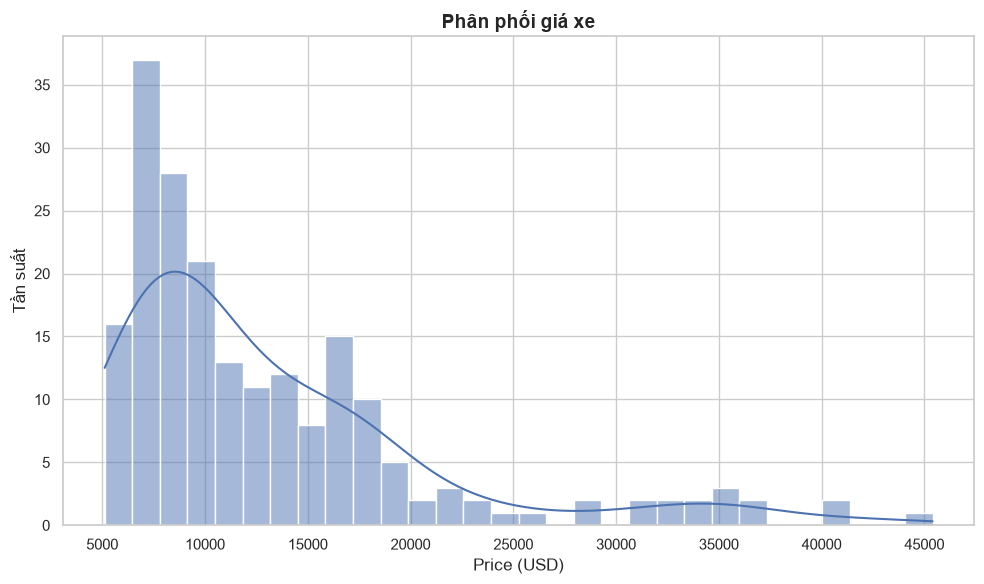

In [71]:
# TODO M2.1: histogram/KDE của price
fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(df_clean['price'].dropna(), kde=True, bins=30, ax=ax)
ax.set_title('Phân phối giá xe', fontsize=14, fontweight='bold')
ax.set_xlabel('Price (USD)')
ax.set_ylabel('Tần suất')
plt.tight_layout()
plt.show()

**Nhận xét:** <!-- 1--2 câu -->

## M2.2 Dataset có cân bằng theo body style không?

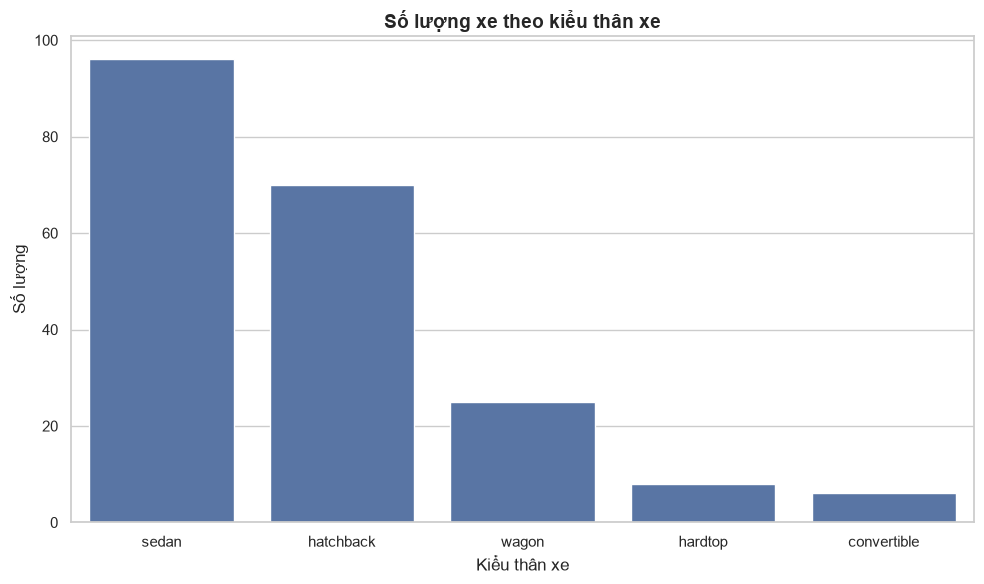

In [72]:
# TODO M2.2: countplot của body_style
fig, ax = plt.subplots(figsize=(10, 6))
sns.countplot(data=df_clean, x='body_style', order=df_clean['body_style'].value_counts().index, ax=ax)
ax.set_title('Số lượng xe theo kiểu thân xe', fontsize=14, fontweight='bold')
ax.set_xlabel('Kiểu thân xe')
ax.set_ylabel('Số lượng')
plt.tight_layout()
plt.show()

**Nhận xét:** <!-- 1--2 câu -->

## M2.3 Price khác nhau theo body style ra sao?

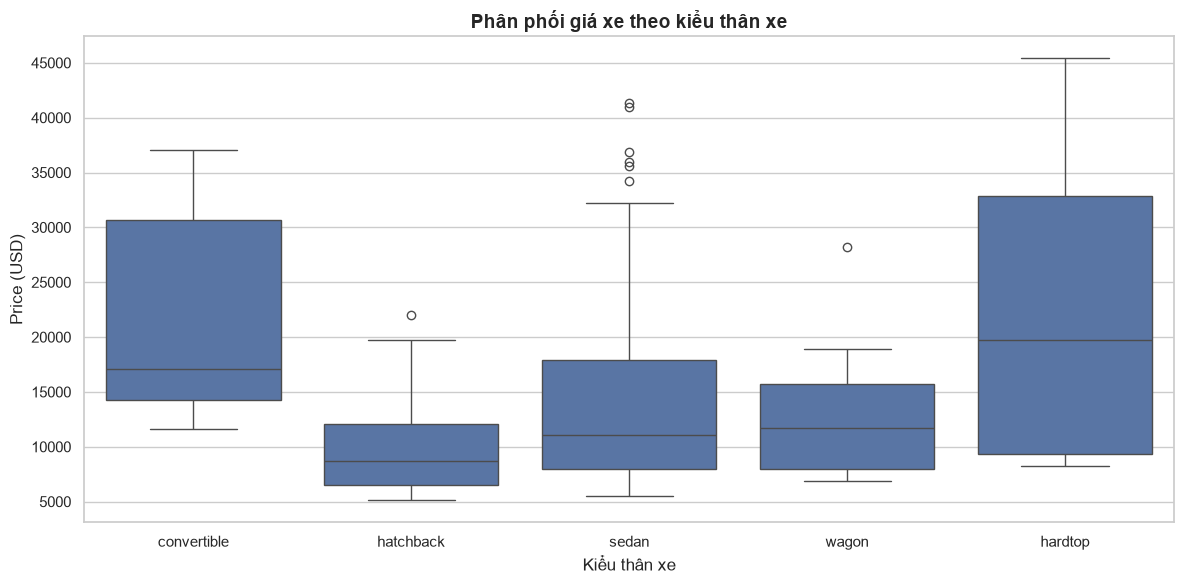

In [73]:
# TODO M2.3: boxplot price theo body_style
fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(data=df_clean, x='body_style', y='price', ax=ax)
ax.set_title('Phân phối giá xe theo kiểu thân xe', fontsize=14, fontweight='bold')
ax.set_xlabel('Kiểu thân xe')
ax.set_ylabel('Price (USD)')
plt.tight_layout()
plt.show()

**Nhận xét:** <!-- 1--2 câu -->

## M2.4 Engine size liên quan thế nào tới price?

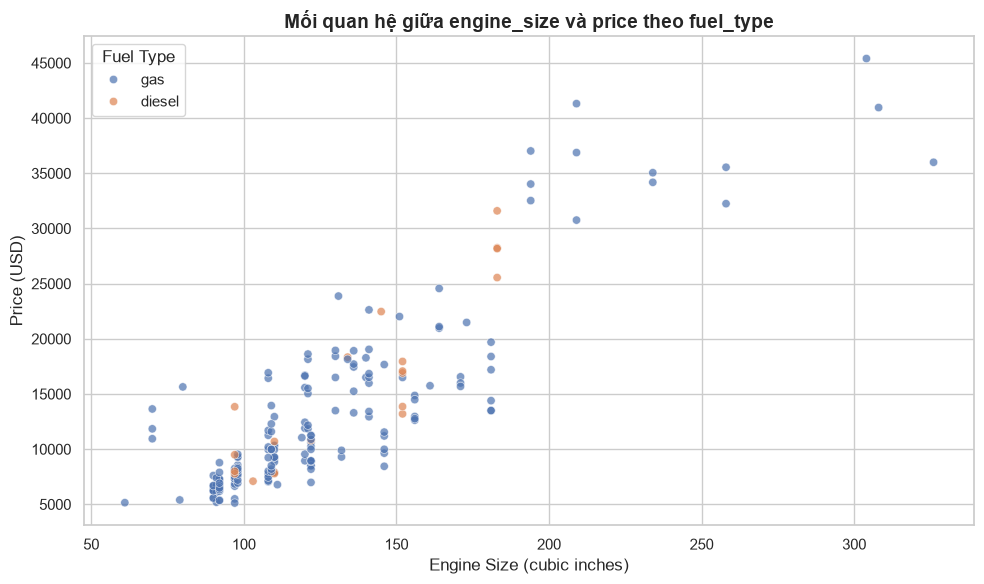

In [74]:
# TODO M2.4: scatterplot engine_size và price, hue=fuel_type
fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(data=df_clean, x='engine_size', y='price', hue='fuel_type', alpha=0.7, ax=ax)
ax.set_title('Mối quan hệ giữa engine_size và price theo fuel_type', fontsize=14, fontweight='bold')
ax.set_xlabel('Engine Size (cubic inches)')
ax.set_ylabel('Price (USD)')
ax.legend(title='Fuel Type')
plt.tight_layout()
plt.show()

**Nhận xét:** <!-- 1--2 câu -->

## M2.5 Các feature numeric tương quan ra sao?

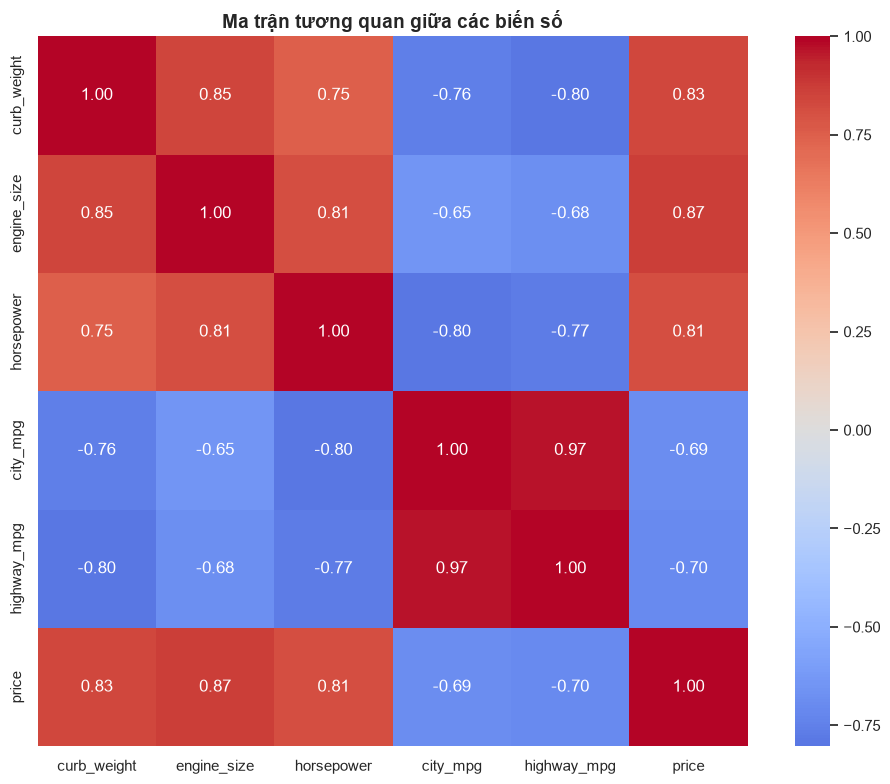

In [75]:
# TODO M2.5: correlation heatmap
fig, ax = plt.subplots(figsize=(10, 8))
corr_matrix = df_clean[AUTO_FEATURES].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True, ax=ax)
ax.set_title('Ma trận tương quan giữa các biến số', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Nhận xét:** <!-- 1--2 câu -->

## M2.6 Biểu đồ tự chọn

Đặt một câu hỏi mới, chọn chart phù hợp và không lặp nguyên năm biểu đồ trên.

C:\Users\PHUC\AppData\Local\Temp\ipykernel_11992\1182184312.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title='Fuel Type')


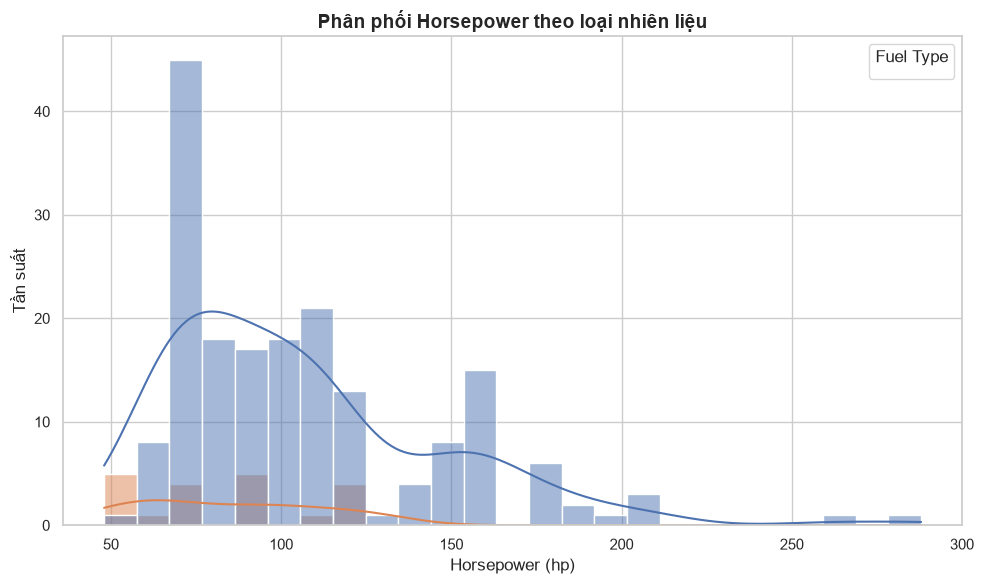

In [76]:
# TODO M2.6: biểu đồ tự chọn
fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(data=df_clean, x='horsepower', hue='fuel_type', kde=True, alpha=0.5, bins=25, ax=ax)
ax.set_title('Phân phối Horsepower theo loại nhiên liệu', fontsize=14, fontweight='bold')
ax.set_xlabel('Horsepower (hp)')
ax.set_ylabel('Tần suất')
ax.legend(title='Fuel Type')
plt.tight_layout()
plt.show()

**Nhận xét:** <!-- 1--2 câu -->

# Tổng hợp

Viết:

- 3--5 phát hiện chính có dẫn chứng;
- ít nhất 2 hạn chế của dataset;
- một ví dụ về correlation không đồng nghĩa causation;
- một câu hỏi nên phân tích tiếp.

## Tổng hợp của sinh viên

<!-- Viết khoảng 150--250 từ. -->

price phân phối lệch phải, với đại đa số xe dưới $20k nhưng có một số xe có giá rất cao.
body_style không đồng đều, trong đó sedan với hatchback là nhiều trong khi convertible và hardtop ít
price trung bình của 2 kiểu convertible với hardtop lại cao hơn đáng kể 2 kiểu kia
engine_size và horse_power tương quan mạnh vơi price, dễ dàng thấy được người ta thường treo giá xe dựa trên mã lực và dung tích(kích cỡ) động cơ.
Nhiều xe gas nhất, nhưng engine_size đều cho ra tương quan dương với price với cả 2 loại nhiên liệu

Cột normalized_loss, bore, stroke thủng lỗ chỗ nên thiếu mẫu để phân tích đa biến.
Số lượng mẫu (200) cho từng này loại ô tô là ít, khó đạt được tính khái quát.

Correlation không đồng nghĩa causation: engine_size và price có tương quan dương, nhưng không có nghĩa là engine_size lớn hơn trực tiếp gây ra giá cao hơn. Thực tế, xe sang thường có động cơ lớn và giá cao, nhưng còn nhiều yếu tố khác như thương hiệu, tiện nghi, chất lượng vật liệu cũng ảnh hưởng. Giá xe trong nhiều trường hợp lại spike cao hơn so với tương quan thực tế do các yếu tố này.

Câu hỏi: Nhiêu đây data là đủ để xây dựng một mô hình đánh giá giá trị xe tổng quát thông qua các yếu tố kĩ thuật(bỏ qua thương hiệu) không?